# In silico ChIP on blood metacells

In [1]:
# Load default settings
here::i_am("revision/blood_trajectory/01_subset_cells.ipynb")

source(here::here("settings.R"))
source(here::here("utils.R"))

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/code



In [2]:
###################
## Load packages
###################
suppressPackageStartupMessages({
    library(scran)
    library(scater)
})
source('../insilico_chip/utils.R')

In [3]:
###################
## I/O
###################
args = list()
args$metacell_folder = file.path(io$basedir, '/results/rna/metacells/all_cells/rna_atac/')
args$RNA_sce = file.path(io$basedir,"data/processed/rna/SingleCellExperiment.rds")
args$ATAC_sce = file.path(io$basedir,"data/processed/atac/archR/Matrices/PeakMatrix_summarized_experiment.rds")
args$outdir = file.path(io$basedir,"results/revisions/blood_trajectory/")
args$trajectory_name = 'blood'
args$metadata =  file.path(args$outdir,sprintf("%s_sample_metadata.txt.gz",args$trajectory_name))
args$metacell_assignment = file.path(args$outdir, 'cell2metacell_assignment.txt.gz')
args$trajectory = file.path(args$outdir, 'blood_trajectory.txt.gz')

#
io$motifmatcher <- file.path(io$basedir, "data/processed/atac/archR/Annotations/CISBP-Scores.rds")
io$motif2gene <- file.path(io$basedir, "data/processed/atac/archR/Annotations/CISBP_motif2gene.txt.gz")
io$background_peaks = file.path(io$basedir,"/data/processed/atac/archR/Background-Peaks.rds")


In [4]:
#######################
## Load RNA and ATAC 
#######################
# Load metadata
metadata = fread(args$metadata)

# Load SingleCellExperiment
rna.sce <- readRDS(args$RNA_sce)[,metadata$cell]

# Load ATAC SummarizedExperiment
atac.sce <- readRDS(args$ATAC_sce)[,metadata$cell]
assayNames(atac.sce) <- "counts"

print(sprintf("Number of cells: %s",length(metadata$cell)))

[1] "Number of cells: 4663"


In [5]:
#######################
## metacells assignment
#######################
metacell_assignment = fread(args$metacell_assignment) %>% 
    .[match(metadata$cell, cell)] %>% 
    .[!is.na(cell)]

rna.sce <- rna.sce[,metacell_assignment$cell]
atac.sce <- atac.sce[,metacell_assignment$cell]

summary(metacell_assignment$cell == colnames(rna.sce))
summary(metacell_assignment$cell == colnames(atac.sce))

print(sprintf("Number of metacells: %s",length(unique(metacell_assignment$metacell))))

library(BiocParallel)
BPPARAM = MulticoreParam(detectCores())

# Compare Ricards function with just this
rna.pb = aggregateAcrossCells(rna.sce, id=metacell_assignment$metacell, BPPARAM = BPPARAM)
atac.pb = aggregateAcrossCells(atac.sce, id=metacell_assignment$metacell, BPPARAM = BPPARAM)

rna.sce_old = rna.sce
atac.sce_old = atac.sce

rna.sce = rna.pb
atac.sce = atac.pb

summary(colnames(rna.sce) == colnames(atac.sce))

assay(rna.sce,"logcounts") <- log(1e6*(sweep(assay(rna.sce),2,colSums(assay(rna.sce),na.rm=T),"/"))+1)
assay(atac.sce,"logcounts") <- log(1e6*(sweep(assay(atac.sce),2,colSums(assay(atac.sce),na.rm=T),"/"))+1)


   Mode    TRUE 
logical    4663 

   Mode    TRUE 
logical    4663 

[1] "Number of metacells: 47"


   Mode    TRUE 
logical      47 

In [6]:
rna.sce

class: SingleCellExperiment 
dim: 32285 47 
metadata(0):
assays(2): counts logcounts
rownames(32285): Xkr4 Gm1992 ... AC234645.1 AC149090.1
rowData names(0):
colnames(47): E7.5_rep1#AAACATGCAGGATAAC-1 E7.5_rep1#AAGCGCTGTTAAGCTG-1
  ... E8.75_rep2#GAGCCACTCATGTCAA-1 E8.75_rep2#TGGCTAAGTAGCCTAA-1
colData names(12): barcode sample ... ids ncells
reducedDimNames(0):
mainExpName: RNA
altExpNames(0):

In [7]:
trajectory = fread(args$trajectory)[match(colnames(rna.sce), cell), c('cell','DC1', 'DC2')]

In [8]:
reducedDim(rna.sce, "DiffusionMap") = trajectory %>% 
    as.data.frame() %>%
    tibble::column_to_rownames('cell') %>% 
    as.matrix()

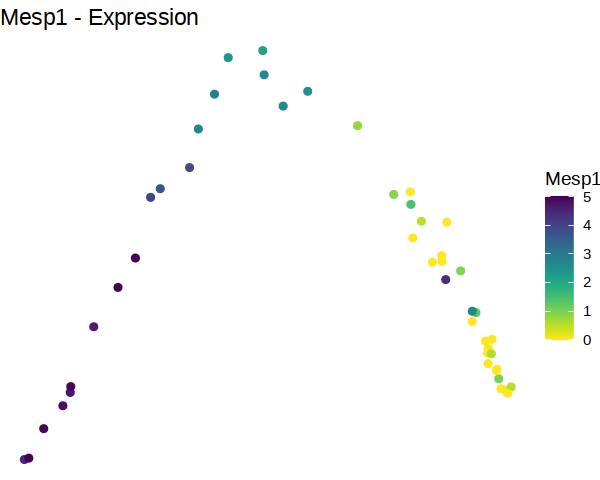

In [9]:
options(repr.plot.width=5, repr.plot.height=4)
gene = 'Mesp1'
ggplot(trajectory, aes(DC1, DC2, col=as.vector(assay(rna.sce[gene,], 'logcounts')))) + 
    geom_point() +
    viridis::scale_color_viridis(begin=1, end=0, name=gene) + 
    ggtitle(paste0(gene, ' - Expression')) + 
    theme_void()

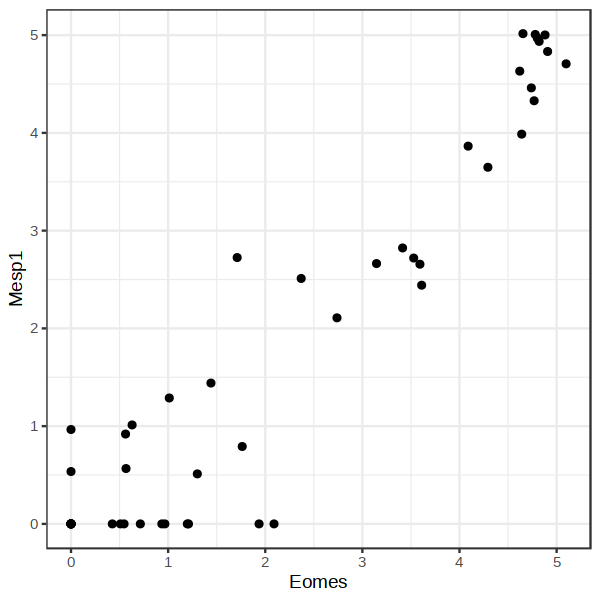

In [10]:
gene1 = 'Eomes'
gene2 = 'Mesp1'
options(repr.plot.width=5, repr.plot.height=5)
ggplot(as.data.table(colData(rna.sce)), aes(as.vector(logcounts(rna.sce[gene1,])), as.vector(logcounts(rna.sce[gene2,])))) + 
                    geom_point() + 
                    xlab(gene1) + ylab(gene2) + 
                    theme_bw()

In [11]:
#######################
## Load Motifs if wanted
#######################
motifmatcher.se <- readRDS(io$motifmatcher)

# Subset peaks
stopifnot(sort(rownames(motifmatcher.se))==sort(rownames(atac.sce)))
motifmatcher.se <- motifmatcher.se[rownames(atac.sce),]

motif2gene.dt <- fread(io$motif2gene)

In [12]:
motifmatcher.se

class: RangedSummarizedExperiment 
dim: 192251 871 
metadata(0):
assays(3): motifScores motifMatches motifCounts
rownames(192251): chr1:3035602-3036202 chr1:3062653-3063253 ...
  chrX:169925487-169926087 chrX:169937064-169937664
rowData names(13): score replicateScoreQuantile ... idx N
colnames(871): TFAP2B_1 TFAP2D_2 ... TBX22_870 TBXT
colData names(1): name

In [13]:
# ##############################
# ## Recalculate motif matches
# ##############################
# # load packages
# suppressPackageStartupMessages({
#     library(motifmatchr)
#     library(chromVARmotifs)
#     library(BSgenome.Mmusculus.UCSC.mm10)
#     library(GenomicRanges)
# })
# # Get motif data
# data("human_pwms_v2")
# motifs <- human_pwms_v2 # mouse_pwms_v2
# obj <- .summarizeChromVARMotifs(motifs)
#   motifs <- obj$motifs
#   motifSummary <- obj$motifSummary


# # Rename TF motifs
# motifSummary$symbol <- motifSummary$name; motifSummary$name <- NULL
# motifSummary$symbol <- toupper(motifSummary$symbol)
# rename <- c(
# TCFE = "TFE", NKX1 = "NKX1-", NKX2 = "NKX2-", NKX3 = "NKX3-", 
# NKX4 = "NKX4-", NKX5 = "NKX5-", NKX6 = "NKX6-", FOXF1A = "FOXF1", 
# HMGA1RS1 = "RS1", `MYCL1$` = "MYCL", `DUX$` = "DUXF3", `DUXBL$` = "DUXBL1", 
# `PIT1$` = "PROP1", ENSMUSG00000079994 = "SOX1", TCFAP = "TFAP"
# )
# motifSummary$symbol <- stringr::str_replace_all(motifSummary$symbol,rename)

# # Convert peaks to genomic ranges object
# peaks = rownames(atac.sce)
# gr <- GRanges(
#     seqnames = Rle(peaks %>% str_split(':') %>% map_chr(1)),
#     ranges = IRanges(start = as.numeric(peaks %>% str_split(':') %>% map_chr(2) %>% str_split('-') %>% map_chr(1)), 
#                      end = as.numeric(peaks %>% str_split(':') %>% map_chr(2) %>% str_split('-') %>% map_chr(2))),
#     strand = Rle(rep('*', length(peaks))))

# motifmatcher_scores.out <- matchMotifs(
#   pwms = motifs,
#   subject = gr,
#   genome = BSgenome.Mmusculus.UCSC.mm10,
#   out = "scores",
#   p.cutoff = 0.0001,
#   w = 7
# )

# rownames(motifmatcher_scores.out) = peaks

In [14]:
###################
## Correlate TF-expr & Region-accessibility
###################  
a = Sys.time()
tf2peak_cor.se = cor_TF_acc(rna.sce, 
                          atac.sce, 
                          TFs_filt = NULL, #str_split(colnames(motifmatcher.se), '_') %>% map_chr(1),  # c('SOX17', 'MYBL1') -> test runs
                          motifmatcher.se = motifmatcher.se, 
                          motif2gene.dt = motif2gene.dt,
                          correlation_method = "pearson", #"spearman", # Options for which corrleation method to use
                          remove_motifs = c("T_789"),
                          cores = detectCores()/2)
b = Sys.time()
b-a

[1] "Removing 0 TFs that have duplicated gene-motif pairs:\n"


Correlate TF-expr & Region-accessibility for 738 TFs



Time difference of 45.56014 secs

In [15]:
tf2peak_cor.se

class: SummarizedExperiment 
dim: 192251 738 
metadata(0):
assays(2): cor pvalue
rownames(192251): chr1:3035602-3036202 chr1:3062653-3063253 ...
  chrX:169925487-169926087 chrX:169937064-169937664
rowData names(1): idx
colnames(738): SOX17 MYBL1 ... YY2 SRY
colData names(0):

In [16]:
# ## Non-linear test
# a = Sys.time()
# non_linear_test = cor_TF_acc(rna.sce, 
#                           atac.sce, 
#                           TFs_filt = NULL, #str_split(colnames(motifmatcher.se), '_') %>% map_chr(1),  # c('SOX17', 'MYBL1') -> test runs
#                           motifmatcher.se = motifmatcher.se, 
#                           motif2gene.dt = motif2gene.dt,
#                           correlation_method = "spearman", #"spearman", # Options for which corrleation method to use
#                           remove_motifs = c("T_789"),
#                           cores = detectCores())
# b = Sys.time()
# b-a

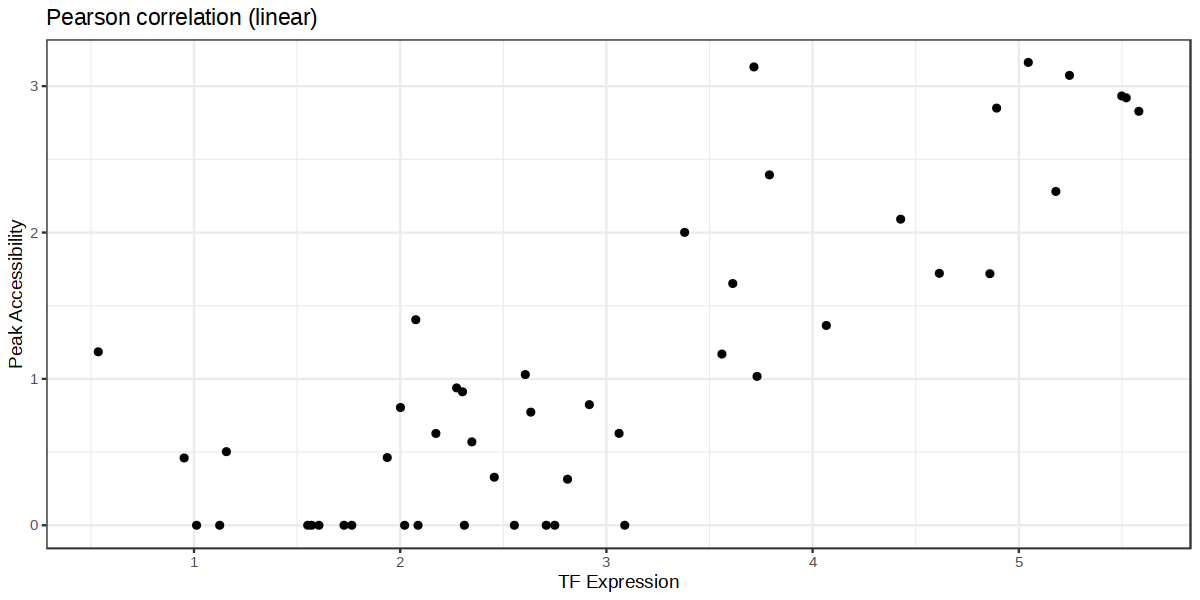

In [17]:
TF = 'GATA2'
i = 100
tmp = as.data.table(as.matrix(assay(tf2peak_cor.se[, TF], 'cor')), keep.rownames=T) %>% setnames(c('peak', 'TF')) %>% .[order(-TF)] %>% head(n=i)
gene = str_to_title(TF)
peak1 = tmp[i,]$peak
p1 = ggplot(as.data.table(colData(rna.sce)), aes(as.vector(logcounts(rna.sce[gene,])), as.vector(assay(atac.sce[peak1,], 'logcounts')))) + 
                    geom_point() + 
                    ggtitle('Pearson correlation (linear)') + 
                    xlab('TF Expression') + ylab('Peak Accessibility') +
                    theme_bw()

# tmp = as.data.table(as.matrix(assay(non_linear_test[, TF], 'cor')), keep.rownames=T) %>% setnames(c('peak', 'TF')) %>% .[order(-TF)] %>% head(n=i)
# peak2 = tmp[i,]$peak
# options(repr.plot.width=5, repr.plot.height=5)
# p2 = ggplot(as.data.table(colData(rna.sce)), aes(as.vector(logcounts(rna.sce[gene,])), as.vector(assay(atac.sce[peak2,], 'logcounts')))) + 
#                     geom_point() + 
#                     ggtitle('Spearman correlation (non-linear)') + 
#                     xlab('TF Expression') + ylab('Peak Accessibility') +
#                     theme_bw()
options(repr.plot.width=10)
# ggarrange(p1, p2)
p1

In [18]:
summary(duplicated(colnames(tf2peak_cor.se)))

   Mode   FALSE 
logical     738 

In [22]:
######################################
## Create virtual chip-seq library 
######################################
a = Sys.time()
motifmatcher_chip = silico_chip(atac.sce = atac.sce, 
                           tf2peak_cor.se = tf2peak_cor.se,
                           motifmatcher.se = motifmatcher.se,
                           motif2gene.dt = motif2gene.dt, 
                           min_number_peaks = 50,
                           TFs_filt = NULL, 
                           remove_motifs = c("T_789"),
                           cores = detectCores()/2)
b = Sys.time()
b-a

[1] "Number of peaks: 192251"
[1] "Predicting TF binding sites..."
[1] "Number of TFs: 738"
[1] "Updating motifmatchr results using the virtual ChIP-seq library..."


Time difference of 31.82131 secs

In [23]:
motifmatcher_chip.se = motifmatcher_chip$motifmatcher_chip.se
virtual_chip.dt = motifmatcher_chip$virtual_chip.dt

In [28]:

head(rownames(atac.sce))

[1] "chr1:3035602-3036202" "chr1:3062653-3063253" "chr1:3072313-3072913"
[4] "chr1:3191496-3192096" "chr1:3340575-3341175" "chr1:3443943-3444543"

In [29]:
######################################
## silico_chipseq_validation
######################################
library(GenomicRanges)
library(rtracklayer)

io$chip_dir.prefix <- "/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/results/revisions/chip_files"
io$chip.files <- c(
  "CDX2" = file.path(io$chip_dir.prefix, "GSM2253707_Cdx2_wtEpiSCs_24h_rep1_mm10.bw"),
  "TAL1" = file.path(io$chip_dir.prefix, "GSM1692858_HP_Tal1.bw"),
  "GATA1" = file.path(io$chip_dir.prefix, "GSM1692851_HP_Gata1.bw"),
  "FOXA2" = file.path(io$chip_dir.prefix, "Foxa2.d5FS.bw"),
  "GATA4" = file.path(io$chip_dir.prefix, "GSM3223330_Gata4.d5FS.r1_m1.ucsc.bigWig"),
  "TBX5" = file.path(io$chip_dir.prefix, "Tbx5_WT_CP.bw")
)
peaks = rownames(atac.sce)
peak_metadata.gr <- GRanges(
    seqnames = Rle(peaks %>% str_split(':') %>% map_chr(1)),
    ranges = IRanges(start = as.numeric(peaks %>% str_split(':') %>% map_chr(2) %>% str_split('-') %>% map_chr(1)), 
                     end = as.numeric(peaks %>% str_split(':') %>% map_chr(2) %>% str_split('-') %>% map_chr(2))),
    strand = Rle(rep('*', length(peaks))))

stopifnot(file.exists(io$chip.files))
TFs <- names(io$chip.files)

## calculate background ChIP signal 
chip_background.dt <- TFs %>% map(function(i) {
  data.table(
    chip_anno = i,
    median = median(import.bw(BigWigFile(io$chip.files[[i]]))$score)
  )
}) %>% rbindlist

## calculate signal 
peak_metadata_ucsc.gr <- peak_metadata.gr; seqlevelsStyle(peak_metadata_ucsc.gr) <- 'UCSC'
peak_metadata_ncbi.gr <- peak_metadata.gr; seqlevelsStyle(peak_metadata_ncbi.gr) <- 'NCBI'
tf2seqstyle <- rep("UCSC",length(TFs)); names(tf2seqstyle) <- TFs
tf2seqstyle["TBX5"] <- "NCBI"

to.plot <- mclapply(TFs, function(i){
  # Load virtual ChIP-seq library
    virtual_chip_tmp = copy(virtual_chip.dt)[tf==i] %>% 
        setnames('peak', 'idx') %>% 
        .[,idx:=str_replace(idx,":","-")] %>%
        .[,chr:=strsplit(idx,"-") %>% map_chr(1)] %>%
        .[,start:=as.integer(strsplit(idx,"-") %>% map_chr(2))] %>%
        .[,end:=as.integer(strsplit(idx,"-") %>% map_chr(3))] %>%
        .[,idx:=str_replace(idx,"-",":")] %>% 
        setkey(chr,start,end)

    # Load ground truth ChIP-seq data
    if (tf2seqstyle[[i]]=="UCSC") {
        tmp <- peak_metadata_ucsc.gr
    } else if (tf2seqstyle[[i]]=="NCBI") {
        tmp <- peak_metadata_ncbi.gr
    }

    chip.dt <- import.bw(BigWigFile(io$chip.files[[i]]), selection = tmp) %>% as.data.table %>%
        .[,c(1,2,3,6)] %>% setnames(c("chr", "start", "end","value")) %>%
        .[,chr:=as.character(chr)] %>%
        .[,chr:=ifelse(grepl("chr",chr),chr,paste0("chr",chr))] %>%
      setkey(chr,start,end)

      # overlap ATAC peaks with ChIP-seq signal and quantify ChIP signal
    to.plot =  virtual_chip_tmp[,c("idx","chr","start","end")] %>%
        foverlaps(chip.dt, nomatch=0) %>% 
        .[,.(value=sum(value)), b=c("idx")] %>%
        merge(virtual_chip_tmp[,c("idx","score","motif_score", "max_accessibility_score")]) %>%
        .[,chip_anno:=as.factor(i)] %>%
        return
  
}, mc.cores=10) %>% rbindlist

seq.ranges <- seq(0,1,by=0.10); names(seq.ranges) <- as.character(1:length(seq.ranges))

foo <- to.plot %>%
  .[score>=0] %>% 
  merge(chip_background.dt,by="chip_anno") %>%
  .[,log_value:=log(value+1)] %>%
  .[,c("chip_anno","idx","log_value","motif_score","score", "max_accessibility_score")] %>%
  setnames("score","score_rna_atac")

to.plot.compare_models <- foo %>%
  # Model 1: DNA
  # .[,score_dna:=minmax.normalisation(motif_score), by="chip_anno"] %>% 
  # Model 2: DNA + ATAC
  .[,score_dna_atac:=minmax.normalisation(max_accessibility_score * motif_score), by="chip_anno"] %>% .[,score_dna_atac:=score_dna_atac+0.001] %>%
  # Model 3: DNA + ATAC + RNA
  .[,score_rna_atac:=minmax.normalisation(score_rna_atac), by="chip_anno"] %>% .[,score_rna_atac:=score_rna_atac+0.001] %>%
  # Discretise values
  # .[,score_dna_group:=cut(abs(score_dna), breaks=seq.ranges)] %>% .[,score_dna_group:=seq.ranges[as.numeric(score_dna_group)]] %>%
  .[,score_dna_atac_group:=cut(abs(score_dna_atac), breaks=seq.ranges)] %>% .[,score_dna_atac_group:=seq.ranges[as.numeric(score_dna_atac_group)]] %>%
  .[,score_rna_atac_group:=cut(abs(score_rna_atac), breaks=seq.ranges)] %>% .[,score_rna_atac_group:=seq.ranges[as.numeric(score_rna_atac_group)]] %>%
  # Prepare for plotting
  melt(id.vars=c("chip_anno","idx","log_value"), measure.vars=c("score_dna_atac_group","score_rna_atac_group"), variable.name="model", value.name="predicted_value") %>%
  .[,N:=.N,by=c("model","chip_anno","predicted_value")] %>%
  .[,.(mean=mean(log_value,na.rm=T), sd=sd(log_value,na.rm=T), N=.N), by=c("model","chip_anno","predicted_value")] %>%
  # Filter settings with a small number of observations
  .[!is.na(mean) & N>=25]

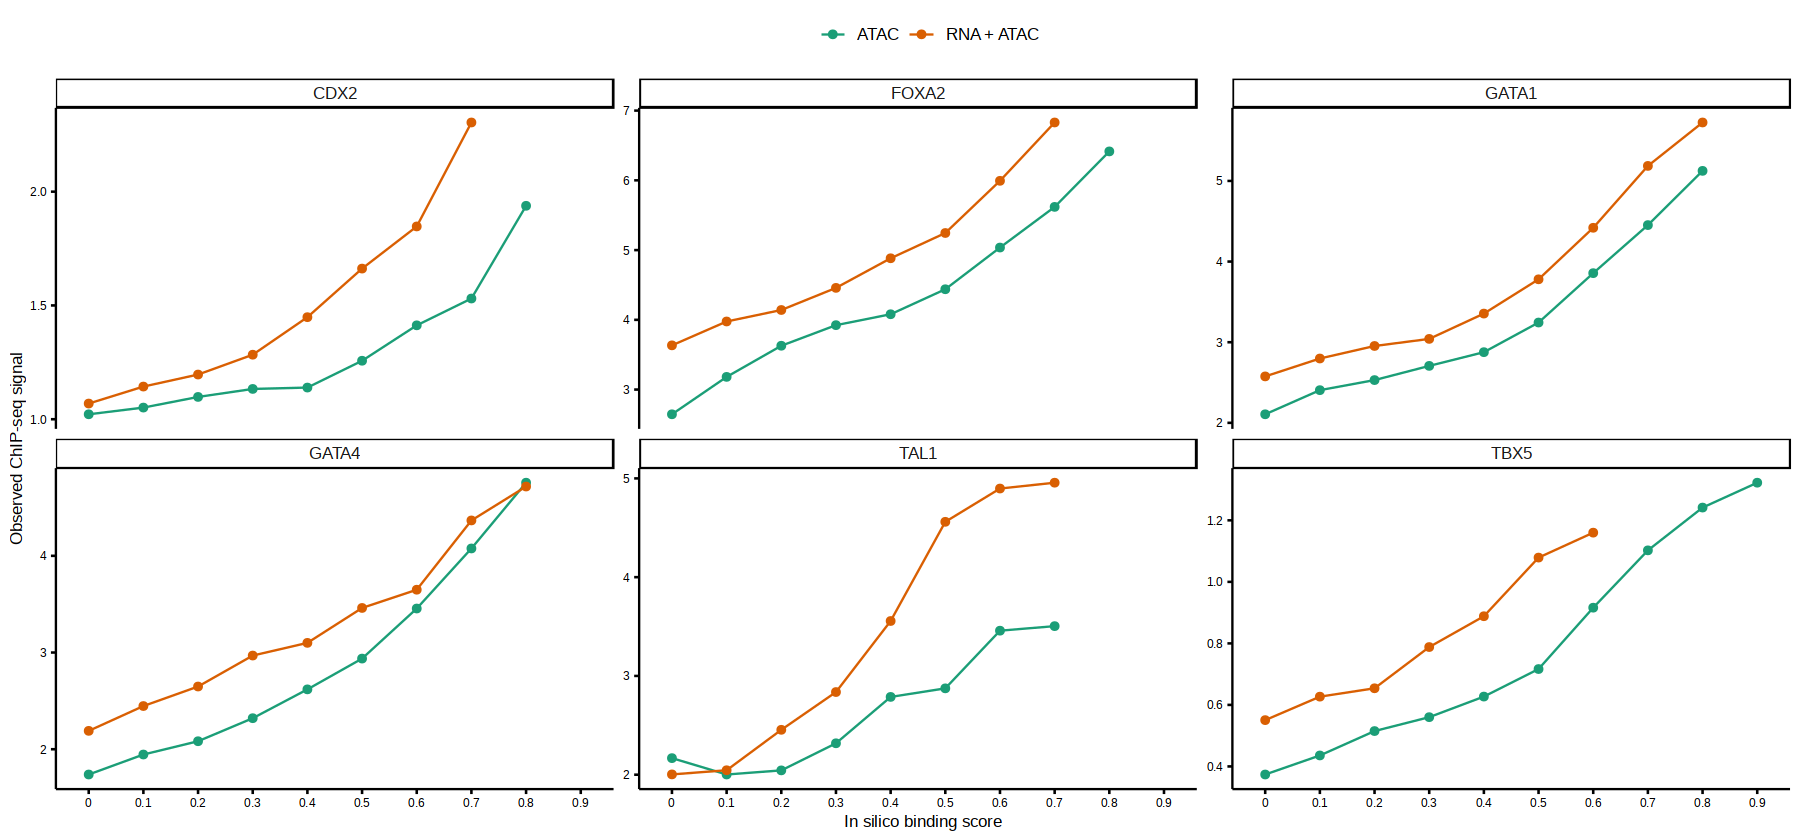

In [30]:
options(repr.plot.width=15, repr.plot.height=7)
ggline(to.plot.compare_models, x="predicted_value", y="mean", color="model", plot_type="b") +
  facet_wrap(~chip_anno, scales="free_y") +
  # geom_errorbar(aes(ymin=log_value-sd, ymax=log_value-sd), width=.2,) +
  scale_color_brewer(palette="Dark2", labels = c("ATAC", "RNA + ATAC")) +
  # scale_color_discrete(labels = c("DNA", "DNA + ATAC", "DNA + ATAC + RNA")) +
  labs(y="Observed ChIP-seq signal", x="In silico binding score") +
  theme(
    strip.background = element_rect(colour="black", fill=NA),
    axis.text = element_text(size=rel(0.55)),
    axis.title = element_text(size=rel(0.8)),
    legend.title = element_blank(),
    # legend.position = c(.26,.87)
    # legend.position = c(.06,.94)
    legend.position = "top"
  )

In [21]:
######################################
## ChromVAR - ChIP-seq
######################################
a = Sys.time()
# load background peak set
bgdPeaks.se <- readRDS(io$background_peaks)

chromvar_deviations.se = chromVAR_chip(atac.sce = atac.sce, 
                                                   motifmatcher_chip.se = motifmatcher_chip.se,
                                                   assay = 'VirtualChipScores',
                                                   background = bgdPeaks.se,
                                                   genome = NULL, # Only needed if background = NULL
                                                   positive_only = TRUE, 
                                                   min_chip_score = 0.15,
                                                   min_number_peaks = 50,
                                                   TFs_filt = NULL,
                                                   test = FALSE,
                                                   method = 'ArchR', # Option 'ArchR' or 'ChromVAR'
                                                   cores = detectCores()/2)
b = Sys.time()
b-a

[1] "Number of matches before filtering negative TF binding values: 18398273"
[1] "Number of matches after filtering negative TF binding values: 10830290"
[1] "Number of matches before filtering based on minimum ChIP-seq score: 10830290"
[1] "Number of matches after filtering based on minimum ChIP-seq score: 1249424"
75 TFs removed because they don't have enough binding sites: ARX ATF4 BACH1 BARX1 BATF3 BCL6B BSX CEBPE CREB3L3 DBP E2F3 FEZF2 FOXL1 HEYL HNF1A HOMEZ HOXA13 HOXA4 HOXA6 HOXC11 HOXD11 HSF4 IRF3 IRF4 IRF8 LBX2 LHX3 MEF2B MYBL2 MYF5 NAIF1 NEUROG3 NKX3-1 NKX6-1 NPAS1 NPAS4 NR1H2 NR2E1 NR4A3 NRL PAX1 PAX2 PAX3 PAX5 PHOX2A PITX3 POU3F4 POU4F1 POU6F2 PPARA PRDM4 RXRB SCRT1 SCRT2 SIX6 SMARCC2 SOX10 SOX15 SOX18 SOX8 SPDEF SPIB SPIC TBX1 TBX15 TBX18 TBX19 TBX2 TBX22 THRB TLX1 TOPORS UNCX ZKSCAN3 ZKSCAN4 
Running ChromVAR-ChIP-seq (ArchR implementation) 


as(<lgCMatrix>, "dgCMatrix") is deprecated since Matrix 1.5-0; do as(., "dMatrix") instead



Time difference of 1.506961 mins

Warning message in as.data.table.list(x, keep.rownames = keep.rownames, check.names = check.names, :
“Item 2 has 20353 rows but longest item has 68938; recycled with remainder.”
Warning message in as.data.table.list(x, keep.rownames = keep.rownames, check.names = check.names, :
“Item 3 has 35578 rows but longest item has 68938; recycled with remainder.”
Warning message in as.data.table.list(x, keep.rownames = keep.rownames, check.names = check.names, :
“Item 4 has 26794 rows but longest item has 68938; recycled with remainder.”
Warning message in as.data.table.list(x, keep.rownames = keep.rownames, check.names = check.names, :
“Item 5 has 32739 rows but longest item has 68938; recycled with remainder.”
Warning message in as.data.table.list(x, keep.rownames = keep.rownames, check.names = check.names, :
“Item 6 has 36572 rows but longest item has 68938; recycled with remainder.”
Warning message in as.data.table.list(x, keep.rownames = keep.rownames, check.names = check.names, :
“Item 7 h

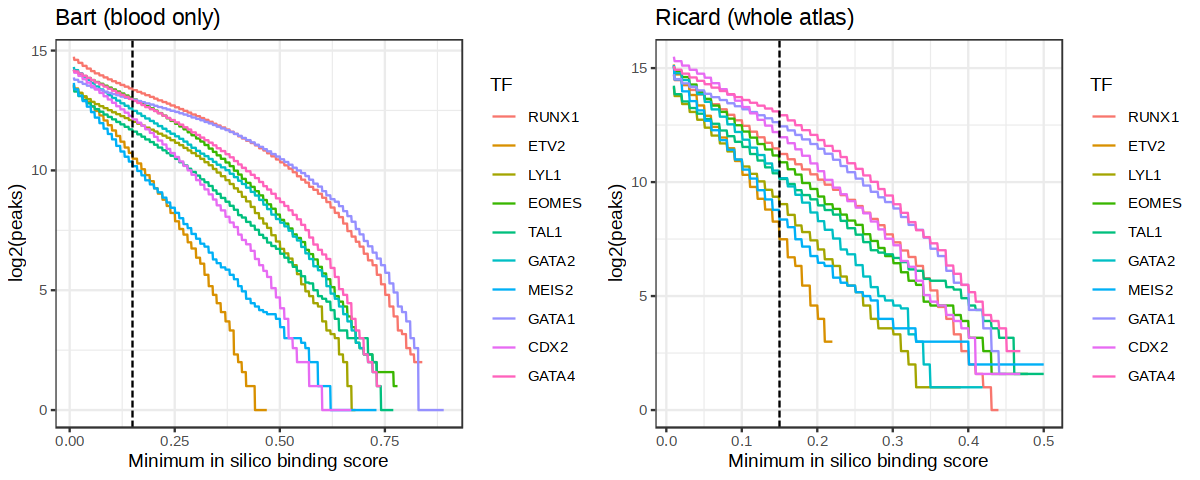

In [22]:
TFs = c('RUNX1', 'ETV2', 'LYL1', 'EOMES', 'TAL1', 'GATA2', 'MEIS2', 'GATA1', 'CDX2', 'GATA4') # 
chip_scores = as.data.table(as.matrix(assay(motifmatcher_chip.se[,TFs], 'VirtualChipScores')))

chip_cutoff = suppressWarnings(mclapply(seq(0.01, 1, by=0.001), function(x){ #
    tmp = chip_scores %>% melt() %>% setnames(c('TF', 'score')) %>% 
        .[score>=x] %>% 
        .[,N:=.N, by='TF'] %>% unique(by='TF')
                                              
    tmp2 = data.table(N = rep(x, nrow(tmp)),
                      TF = tmp$TF,
                      peaks = tmp$N)
    return(tmp2)
}, mc.cores=detectCores())) %>% rbindlist()

p1 = ggplot(chip_cutoff, aes(N, log2(peaks), col=TF, group=TF)) + 
    geom_line() + 
    geom_vline(xintercept=0.15, linetype='longdash') +
    xlab('Minimum in silico binding score') + 
    ggtitle('Bart (blood only)') +
    theme_bw()

ricard_chip = lapply(TFs, function(x){
    tmp = fread(sprintf('%s/results/rna_atac/virtual_chipseq/metacells/CISBP/%s.txt.gz',io$basedir, x)) %>%
        .[,'score'] %>% setnames(x)
    return(tmp)
}) %>% do.call('cbind', .)

ricard_cutoff = suppressWarnings(mclapply(seq(0.01, 1, by=0.001), function(x){ #
    tmp = ricard_chip %>% melt() %>% setnames(c('TF', 'score')) %>% 
        .[score>=x] %>% 
        .[,N:=.N, by='TF'] %>% unique(by='TF')
                                              
    tmp2 = data.table(N = rep(x, nrow(tmp)),
                      TF = tmp$TF,
                      peaks = tmp$N)
    return(tmp2)
}, mc.cores=detectCores())) %>% rbindlist()

p2 = ggplot(ricard_cutoff, aes(N, log2(peaks), col=TF, group=TF)) + 
    geom_line() + 
    geom_vline(xintercept=0.15, linetype='longdash') +
    xlab('Minimum in silico binding score') + 
    ggtitle('Ricard (whole atlas)') +
    theme_bw()

options(repr.plot.width=10, repr.plot.height=4)
ggarrange(p1, p2)

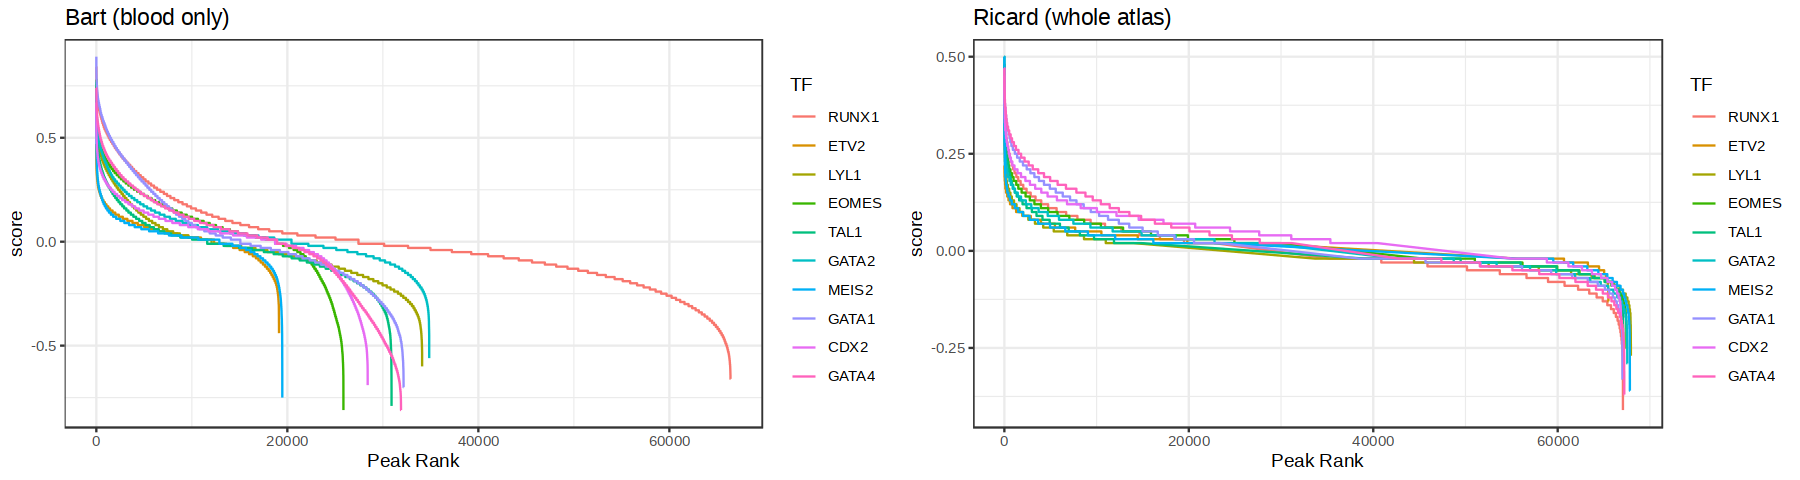

In [23]:
chip_score = suppressWarnings(mclapply(TFs, function(x){ #
    tmp = chip_scores %>% melt() %>% setnames(c('TF', 'score')) %>% 
        .[abs(score)>0] %>% 
        .[TF==x] %>% 
        .[order(-score)] %>% 
        .[,I:=.I]
                                    
    return(tmp)
}, mc.cores=detectCores())) %>% rbindlist()

p1 = ggplot(chip_score, aes(I, score, col=TF, group=TF)) + 
    geom_line() + 
    xlab('Peak Rank') + 
    ggtitle('Bart (blood only)') +
    theme_bw()

ricard_scores = suppressWarnings(mclapply(TFs, function(x){ #
    tmp = ricard_chip %>% melt() %>% setnames(c('TF', 'score')) %>% 
        .[TF==x] %>% 
        .[order(-score)] %>% 
        .[,I:=.I] %>% .[abs(score)>0.01]
                                    
    return(tmp)
}, mc.cores=detectCores())) %>% rbindlist()

options(repr.plot.width=15, repr.plot.height=4)
p2 = ggplot(ricard_scores, aes(I, score, col=TF, group=TF)) + 
    geom_line() + 
    xlab('Peak Rank') + 
    ggtitle('Ricard (whole atlas)') +
    theme_bw()

ggarrange(p1, p2)

In [25]:
save_bed = function(TF, score_thr=1e-10, abs=TRUE){
    peaks = rownames(motifmatcher_chip.se)
    tmp = data.table(chr = str_split(peaks, ':') %>% map_chr(1),
                     start = str_split(str_split(peaks, ':') %>% map_chr(2), '-') %>% map_chr(1),
                     end = str_split(str_split(peaks, ':') %>% map_chr(2), '-') %>% map_chr(2),
                     score = as.matrix(assay(motifmatcher_chip.se[,TF], 'VirtualChipScores'))) %>%
        setnames(c('chr', 'start', 'end', 'score'))
    if(abs){
        tmp = tmp[abs(score)>=score_thr] 
    }else{
        tmp = tmp[score>=score_thr] 
    }
    fwrite(tmp, sprintf('%s/silico_chip/%s.bed.gz', args$outdir, TF))
    return(tmp)    
}

beds = mclapply(c('GATA1', 'TAL1', 'FLI1', 'GATA2', 'RUNX1', 'CDX2'), save_bed, score_thr=1e-10, abs=TRUE, mc.cores=3) %>% rbindlist()


In [ ]:
create_bed = function(TF, score_thr=1e-10){
    peaks = rownames(motifmatcher_chip.se)
    tmp = data.table(chr = str_split(peaks, ':') %>% map_chr(1),
                     start = str_split(str_split(peaks, ':') %>% map_chr(2), '-') %>% map_chr(1),
                     end = str_split(str_split(peaks, ':') %>% map_chr(2), '-') %>% map_chr(2),
                     name = TF,
                     score = as.matrix(assay(motifmatcher_chip.se[,TF], 'VirtualChipScores'))) %>%
        setnames(c('chr', 'start', 'end', 'name', 'score')) %>%
        .[score>=score_thr] %>%
        .[,score:=score*1000]
    
    return(tmp)
}

In [ ]:
test = create_bed('TAL1', score_thr=-1)

In [ ]:
beds = mclapply(c('GATA1', 'TAL1', 'FLI1', 'GATA2', 'RUNX1',), create_bed, mc.cores=3) %>% rbindlist()
fwrite(beds, file.path(args$outdir, 'beds.bed'), sep='\t', quote=FALSE, col.names = FALSE)

In [25]:
chromvar_deviations_original.se = chromVAR_chip(atac.sce = atac.sce, 
                                                   motifmatcher_chip.se = motifmatcher_chip.se,
                                                   assay = 'motifScores',
                                                   background = bgdPeaks.se,
                                                   genome = NULL, # Only needed if background = NULL
                                                   positive_only = FALSE, 
                                                   min_chip_score = 0,
                                                   min_number_peaks = 50,
                                                   TFs_filt = NULL,
                                                   test = FALSE,
                                                   method = 'ArchR', # Option 'ArchR' or 'ChromVAR'
                                                   cores = detectCores())

[1] "Number of matches before filtering based on minimum ChIP-seq score: 18398273"
[1] "Number of matches after filtering based on minimum ChIP-seq score: 18398273"
Running ChromVAR-ChIP-seq (ArchR implementation) 


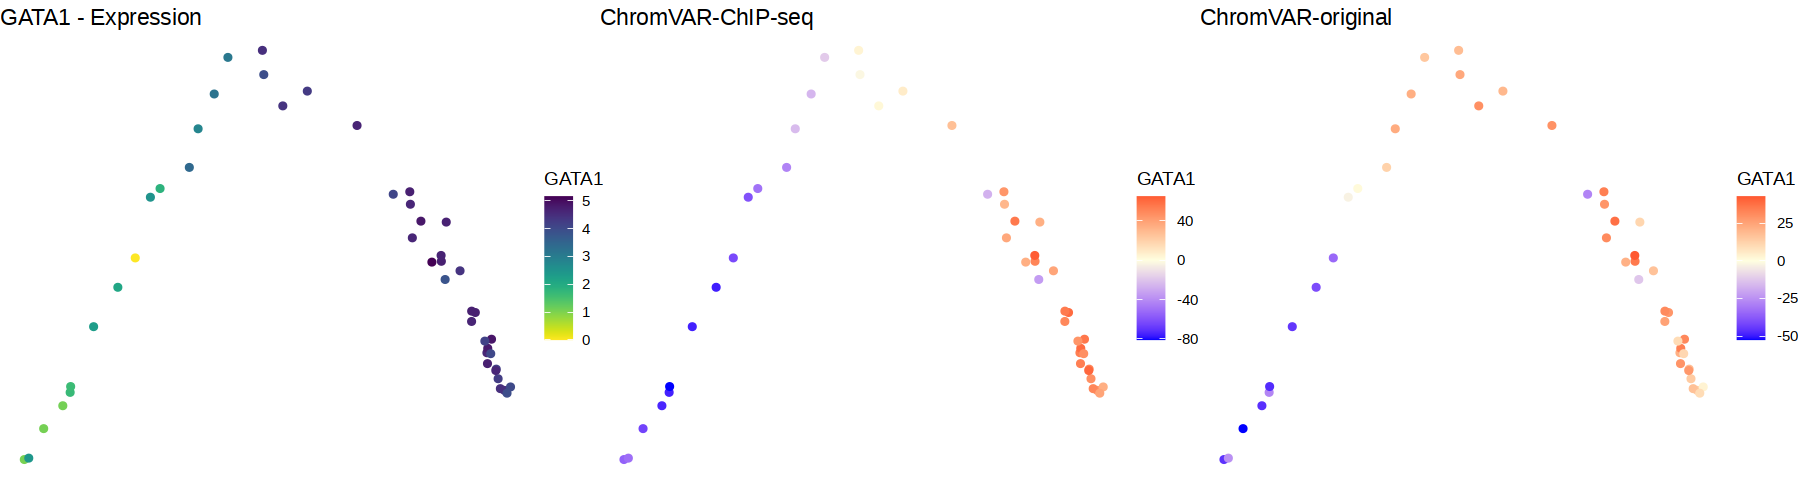

In [28]:
TF = 'GATA1'
if(TF %in% rownames(chromvar_deviations.se) & TF %in% rownames(chromvar_deviations_original.se)){
    p1 = ggplot(trajectory, aes(DC1, DC2, col=as.vector(assay(rna.sce, 'logcounts')[str_to_title(TF),]))) + 
        geom_point() +
        viridis::scale_color_viridis(begin=1, end=0, name=TF) + 
        ggtitle(paste0(TF, ' - Expression')) + 
        theme_void()

    p2 = ggplot(trajectory, aes(DC1, DC2, col=as.vector(assay(chromvar_deviations.se, 'z')[TF,]))) + 
        geom_point() +
        scale_color_gradient2(low='blue', mid='lightyellow', high='red', name=TF) + 
        ggtitle('ChromVAR-ChIP-seq') + 
        theme_void()

    p3 = ggplot(trajectory, aes(DC1, DC2, col=as.vector(assay(chromvar_deviations_original.se, 'z')[TF,]))) + 
        geom_point() +
        scale_color_gradient2(low='blue', mid='lightyellow', high='red', name=TF) + 
        ggtitle('ChromVAR-original') + 
        theme_void()
    options(repr.plot.width=15, repr.plot.height=4)
    ggarrange(p1, p2, p3, nrow = 1)
}

In [ ]:
TF_correlations = mclapply(unique(rownames(chromvar_deviations.se)), function(x){
      corr_output <- psych::corr.test(
        x = as.vector(assay(chromvar_deviations.se[x,], 'z')), 
        y = as.vector(assay(rna.sce[str_to_title(x),], 'logcounts')), 
        ci = FALSE,
        method = 'pearson'
      )
    
    tmp = data.table(tf = x,
                     cor = round(corr_output$r,3),
                     pval = round(corr_output$p,10))
    return(tmp)
}, mc.cores = detectCores()) %>% rbindlist() %>%
    .[order(-cor)] %>%
    .[,rank:=.I]

In [ ]:
options(repr.plot.width=7, repr.plot.height=4)
ggplot(TF_correlations, aes(rank, cor)) + 
    geom_point(col='gray80') +
    ggrepel::geom_text_repel(data = head(TF_correlations, 10), 
                             aes(label=tf), 
                             max.overlaps=Inf, 
                             box.padding=0.5) + 
    ggtitle('TF-ChromVAR correlations') + 
    ylab('Correlation score') + 
    theme_bw()

In [ ]:
######################################
## link TF2genes virtual chip
######################################
# peak2gene (also possible to find them in the function, need to supply gene metadata with gene locations(e.g. from biomaRt))
peak2gene <- file.path(io$basedir,"results/atac/archR/peak_calling/peaks2genes/peaks2genes_all.txt.gz") 

## Load peak2gene linkages using only genomic distance
peak2gene.dt <- fread(peak2gene)
head(peak2gene.dt)
summary(peak2gene.dt$dist)

a = Sys.time()
TF2Gene_links = TF2Gene(rna.sce = rna.sce, 
                   motifmatcher_chip.se = motifmatcher_chip.se,
                   peak2gene.dt = peak2gene.dt,
                   min_chip_score = 0.15,
                   distance = 1.5e5, # Can not be higher than the max distance in peak2gene.dt, unless recalculated from gene metadata file
                   cores = detectCores())
b = Sys.time()
b-a
head(TF2Gene_links)

In [ ]:
head(TF2Gene_links[order(-beta)])

In [ ]:
gene1 = 'Nfe2'
gene2 = 'Hba-x'
options(repr.plot.width=5, repr.plot.height=5)
ggplot(as.data.table(colData(rna.sce)), aes(as.vector(logcounts(rna.sce[gene1,])), as.vector(logcounts(rna.sce[gene2,])))) + 
                    geom_point() + 
                    theme_bw()

In [ ]:
# Inspect silico ChIP-scores & TF-gene beta values
options(repr.plot.width=20, repr.plot.height=3)
chip_scores = as.vector(assay(motifmatcher_chip.se, 'VirtualChipScores'))
chip_scores = chip_scores[abs(chip_scores)>0.01]
p1 = gghistogram(chip_scores[abs(chip_scores)<quantile(abs(chip_scores), 0.99)], bins=100) + ggtitle('in silico ChIP-scores')
p2 = gghistogram(TF2Gene_links$beta[abs(TF2Gene_links$beta)>0.05 & abs(TF2Gene_links$beta)<quantile(abs(TF2Gene_links$beta), 0.99)], bins=100) + ggtitle('TF-gene beta values')
ggarrange(p1, p2)

In [ ]:
suppressMessages(library(GGally))
suppressMessages(library(igraph))
suppressMessages(library(ggraph))
suppressMessages(library(igraph))
suppressMessages(library(tibble))
suppressMessages(library(tidygraph))

In [ ]:
tf2gene_chip = function(motifmatcher_chip.se = motifmatcher_chip.se,
                        assay = 'VirtualChipScores',
                        max_distance = 1.5e5,
                        min_chip_score = 0.1,
                        min_beta = 0.1,
                        min_pvalue = 0.1,
                        min_TF_expr = 5, # Min logcounts
                        TF_filter = NULL, #c('GATA1', 'TAL1', 'HOXB8', 'LYL1')#c('HOXB8')
                        TF_TF_only = TRUE,
                        rna.sce = rna.sce,
                        min_targets = 3,
                        cores = detectCores()
                        ){
    
    tf2gene_chip.dt = mclapply(colnames(assay(motifmatcher_chip.se, assay)), function(i){
            virtual_chip.mtx = assay(motifmatcher_chip.se, assay)
            # Select target peaks (note that we only take positive correlations into account)
            target_peaks_i <- names(which(virtual_chip.mtx[,i]>=min_chip_score))
            if (length(target_peaks_i)>=1) {
                tmp <- data.table(
                  tf = i,
                  peak = target_peaks_i,
                  chip_score = virtual_chip.mtx[target_peaks_i,i]
                ) %>% merge(peak2gene.dt[peak %in% target_peaks_i,c("peak","gene","dist")], by="peak")
                return(tmp)
                }
            }, mc.cores=cores) %>% rbindlist %>%
            .[,gene:=toupper(gene)] %>%
            .[chip_score >= min_chip_score & dist <= max_distance]

    options(repr.plot.width=6, repr.plot.height=3)
    max_expr = data.table(tf = unique(tf2gene_chip.dt$tf),
                          max_expr = rowMaxs(logcounts(rna.sce[str_to_title(unique(tf2gene_chip.dt$tf)),])))

    gghistogram(max_expr$max_expr) + ggtitle('Max expression of TFs')
    TF_keep = max_expr[max_expr>=min_TF_expr, toupper(tf)]

    GRN_coef.dt <- TF2Gene_links %>% 
      .[pvalue<min_pvalue & abs(beta)>=min_beta] %>%
      .[,gene:=toupper(gene)] %>%
      .[tf %in% TF_keep]
    if(!is.null(TF_filter)){
        GRN_coef.dt = GRN_coef.dt[tf %in% TF_filter]
    }
    if(TF_TF_only){
        GRN_coef.dt = GRN_coef.dt[gene %in% tf]
    }

    GRN.dt = merge(GRN_coef.dt, tf2gene_chip.dt, by=c('tf', 'gene')) %>% 
        .[,c('tf', 'peak', 'gene', 'dist', 'chip_score', 'beta', 'pvalue')] %>% 
        unique(by=c('tf', 'gene')) %>%
        .[,c('tf', 'gene', 'beta')] %>% 
        .[,N := .N, by='tf'] %>%
        .[N >= min_targets] 

    if(TF_TF_only){
        GRN.dt = GRN.dt[gene %in% tf]
    }
    
    return(GRN.dt)
}

In [ ]:
test = tf2gene_chip(motifmatcher_chip.se = motifmatcher_chip.se,
                        assay = 'VirtualChipScores',
                        max_distance = 1.5e5,
                        min_chip_score = 0.1,
                        min_beta = 0.1,
                        min_pvalue = 0.1,
                        min_TF_expr = 5, # Min logcounts
                        TF_filter = NULL, #c('GATA1', 'TAL1', 'HOXB8', 'LYL1')#c('HOXB8')
                        TF_TF_only = TRUE,
                        rna.sce = rna.sce,
                        min_targets = 3,
                        cores = detectCores())
head(test)

In [ ]:
#################
## Build GRN
#################
max_distance = 1.5e5
min_chip_score = 0.1
min_beta = 0.1
min_pvalue = 0.1
min_TF_expr = 2 # Min logcounts
TF_filter = NULL #c('GATA1', 'TAL1', 'HOXB8', 'LYL1')#c('HOXB8')
TF_TF_only = TRUE
motifmatcher_chip.se = motifmatcher_chip.se
assay = 'VirtualChipScores'
rna.sce = rna.sce
min_targets = 3
cores = detectCores()

In [ ]:
tf2gene_chip.dt <- mclapply(colnames(assay(motifmatcher_chip.se, assay)), function(i){
        virtual_chip.mtx = assay(motifmatcher_chip.se, assay)
        # Select target peaks (note that we only take positive correlations into account)
        target_peaks_i <- names(which(virtual_chip.mtx[,i]>=min_chip_score))
        if (length(target_peaks_i)>=1) {
            tmp <- data.table(
              tf = i,
              peak = target_peaks_i,
              chip_score = virtual_chip.mtx[target_peaks_i,i]
            ) %>% merge(peak2gene.dt[peak %in% target_peaks_i,c("peak","gene","dist")], by="peak")
            return(tmp)
            }
        }, mc.cores=cores) %>% rbindlist %>%
        .[,gene:=toupper(gene)] %>%
        .[chip_score >= min_chip_score & dist <= max_distance]

options(repr.plot.width=6, repr.plot.height=3)
max_expr = data.table(tf = unique(tf2gene_chip.dt$tf),
                      max_expr = rowMaxs(logcounts(rna.sce[str_to_title(unique(tf2gene_chip.dt$tf)),])))

gghistogram(max_expr$max_expr) + ggtitle('Max expression of TFs')
TF_keep = max_expr[max_expr>=min_TF_expr, toupper(tf)]

GRN_coef.dt <- TF2Gene_links %>% 
  .[pvalue<min_pvalue & abs(beta)>=min_beta] %>%
  .[,gene:=toupper(gene)] %>%
  .[tf %in% TF_keep]
if(!is.null(TF_filter)){
    GRN_coef.dt = GRN_coef.dt[tf %in% TF_filter]
}
if(TF_TF_only){
    GRN_coef.dt = GRN_coef.dt[gene %in% tf]
}

GRN.dt = merge(GRN_coef.dt, tf2gene_chip.dt, by=c('tf', 'gene')) %>% 
    .[,c('tf', 'peak', 'gene', 'dist', 'chip_score', 'beta', 'pvalue')] %>% 
    unique(by=c('tf', 'gene')) %>%
    .[,c('tf', 'gene', 'beta')] %>% 
    .[,N := .N, by='tf'] %>%
    .[N >= min_targets] 

if(TF_TF_only){
    GRN.dt = GRN.dt[gene %in% tf]
}

In [ ]:
# Create node and edge data.frames
TFs <- unique(c(GRN.dt$tf,GRN.dt$gene))
node_list.dt <- data.table(node_id=1:length(TFs), node_name=TFs)
edge_list.dt <- GRN.dt[,c("tf","gene","beta")] %>% setnames(c("from","to","weight")) %>% .[!from==to]

# Create igraph object
igraph.net <- graph_from_data_frame(d = edge_list.dt)

# Create tbl_graph object for ggraph
igraph.tbl <- as_tbl_graph(igraph.net) %>%
  activate(nodes) %>%
  mutate(tf=names(V(igraph.net))) %>%
  mutate(degree=igraph::degree(igraph.net)) %>%
  mutate(eigen_centrality=eigen_centrality(igraph.net)$vector) %>%
  activate(edges) %>%
  mutate(sign=ifelse(E(igraph.net)$weight>0,"Positive","Negative")) %>%
  mutate(weight=abs(weight))

In [ ]:
options(repr.plot.width=20, repr.plot.height=15)

ggraph(igraph.tbl, 'kk') +
  geom_edge_link(aes(edge_colour = sign, alpha=weight), edge_width=0.15, arrow=arrow(length=unit(1.5,'mm')), end_cap=circle(4,'mm')) +
  scale_edge_colour_manual(values=c("Positive"="darkgreen", "Negative"="darkred")) +
  geom_node_point(size=9, alpha=0.75, col='lightblue') +
  geom_node_text(aes(label = name)) +
  theme_graph()

In [ ]:
# Create node and edge data.frames
GRN.dt = GRN.dt[beta>0]
TFs <- unique(c(GRN.dt$tf,GRN.dt$gene))
node_list.dt <- data.table(node_id=1:length(TFs), node_name=TFs)
edge_list.dt <- GRN.dt[,c("tf","gene","beta")] %>% setnames(c("from","to","weight")) %>% .[!from==to]

# Create igraph object
igraph.net <- graph_from_data_frame(d = edge_list.dt)

# Create tbl_graph object for ggraph
igraph.tbl <- as_tbl_graph(igraph.net) %>%
  activate(nodes) %>%
  mutate(tf=names(V(igraph.net))) %>%
  mutate(degree=igraph::degree(igraph.net)) %>%
  mutate(eigen_centrality=eigen_centrality(igraph.net)$vector) %>%
  activate(edges) %>%
  mutate(sign=ifelse(E(igraph.net)$weight>0,"Positive","Negative")) %>%
  mutate(weight=abs(weight))

In [ ]:
options(repr.plot.width=20, repr.plot.height=15)

ggraph(igraph.tbl, 'kk') +
  geom_edge_link(aes(edge_colour = sign, alpha=weight), edge_width=0.15, arrow=arrow(length=unit(1.5,'mm')), end_cap=circle(4,'mm')) +
  scale_edge_colour_manual(values=c("Positive"="darkgreen", "Negative"="darkred")) +
  geom_node_point(size=9, alpha=0.75, col='lightblue') +
  geom_node_text(aes(label = name)) +
  theme_graph()

In [ ]:
head(tf2gene_chip.dt)

In [ ]:
chip_GRN = merge(tf2gene_chip.dt, GRN.dt, by=c('tf', 'gene')) %>%
    .[tf!=gene] # remove auto regulation because it messes up the plot

In [ ]:
## test
#TFs = c('FLI1', 'GATA2', 'KLF1', 'TAL1')
TFs = unique(chip_GRN$tf)
#TFs = c('POU5F1', 'NANOG')
chip_GRN_i = chip_GRN[gene %in% tf][chip_score>0.2 & abs(beta) > 0.15]

# Clear up network to keep only TFs with multiple connection with new thresholds set
TFs <- intersect(chip_GRN_i[,.N,by="tf"][N>=3,tf], chip_GRN_i[,.N,by="gene"][N>=3,gene])
chip_GRN_i <- chip_GRN_i[tf%in%TFs & gene%in%TFs]


TF_peak = chip_GRN_i[tf%in%TFs, c('tf', 'peak', 'chip_score')] %>% .[,sign:='Positive'] %>% .[,chip_score:=minmax.normalisation(chip_score)]
peak_gene = chip_GRN_i[tf%in%TFs, c('peak', 'gene', 'beta')] %>%  .[,sign:=ifelse(beta>0, 'Positive', 'Negative')]  %>% .[,beta:=abs(beta)] # %>% .[,beta:=minmax.normalisation(abs(beta))]

In [ ]:
summary(chip_GRN_i$beta)

In [ ]:
TF.node = TF_peak[,c('tf')] %>% 
    unique(by='tf') %>% 
    setnames(c('node')) %>% 
    .[,type:='TF'] 
peak.node =  peak_gene[,c('peak')] %>% 
    unique(by='peak') %>% 
    setnames(c('node')) %>% 
    .[,type:='peak']
gene.node = chip_GRN_i[tf%in%TFs, 'gene'] %>%
    unique(by='gene') %>% 
    setnames('node' ) %>% 
    .[,type:=ifelse(node %in% unique(GRN_coef.dt$tf), 'TF', 'target')]
nodes.dt = rbind(TF.node, peak.node, gene.node) %>% unique(by='node')

In [ ]:
edges.dt = rbind(TF_peak, peak_gene,use.names=FALSE) %>% setnames(c('node', 'target', 'score', 'sign')) #%>% unique(by=c('node', 'target'))

In [ ]:
igraph.tbl = tbl_graph(nodes = nodes.dt, edges = edges.dt)# %>%
   # activate(edges) #%>%
   # mutate(sign=ifelse(score>0, 'Positive', 'Negative')) %>%
   # mutate(score=abs(score))

In [ ]:
options(repr.plot.width=20, repr.plot.height=8)

ggraph(igraph.tbl, 'stress') +
    # Edges
    geom_edge_link(aes(edge_alpha=1, edge_color=sign), edge_width=0.3, arrow=arrow(length=unit(4,'mm')), end_cap=circle(4,'mm'), show.legend = T) +
    scale_edge_alpha_continuous(range=c(0,max(edges.dt$score))) +
    scale_edge_colour_manual(values=c("Positive"="#08c20e", "Negative"="darkred")) +
    # Nodes
    geom_node_point(aes(size=ifelse(type=='TF', 5, 1), color=type)) + #, size=14
    geom_node_text(aes(filter=type=='TF' , label=node, size=2)) + # , size=3.75| type=='target'
    scale_alpha_continuous(range=c(0.0,1)) +
    # theme
    theme_graph() + theme(
      legend.position = "none"
    ) + 
    ggtitle('Total GRN')

In [ ]:
io$cell2metacell <- file.path(io$outdir, "cell2metacell_assignment.txt.gz")


In [ ]:
cell2metacell = fread(io$cell2metacell)

In [ ]:
gghistogram(cell2metacell %>% unique(by='metacell') %>% .$celltype_purity)

In [ ]:
head(cell2metacell)